# Objetivo: Criar um modelo para prever o churn dos clientes do banco

# Sobre o dataset

Abaixo está o mapeamento e a descrição de cada um dos atributos presentes no conjunto de dados:

- `RowNumber` (Numérico): Corresponde ao número do registro (linha).

- `CustomerId` (Numérico): Identificador único do cliente.

- `Surname` (Texto): Sobrenome do cliente.

- `CreditScore` (Numérico): Pontuação de crédito do cliente.

- `Geography` (Categórico): Localização geográfica do cliente.

- `Gender` (Categórico): Gênero do cliente.

- `Age` (Numérico): Idade do cliente.

- `Tenure` (Numérico): Número de anos que o cliente está com o banco.

- `Balance` (Numérico): Saldo bancário do cliente.

- `NumOfProducts` (Numérico): Quantidade de produtos que o cliente adquiriu ou utiliza no banco.

- `HasCrCard` (Binário): Indica se o cliente possui ou não cartão de crédito.

- `IsActiveMember` (Binário): Indica se o cliente é um membro ativo no banco.

- `EstimatedSalary` (Numérico): Salário estimado do cliente.

- `Complain` (Binário): Indica se o cliente fez uma reclamação.

- `Satisfaction Score` (Numérico): Pontuação de satisfação dada pelo cliente em relação à resolução de sua reclamação.

- `Card Type` (Categórico): Tipo de cartão que o cliente possui (ex: Gold, Platinum, Diamond).

- `Point Earned` (Numérico): Pontos acumulados pelo cliente ao utilizar o cartão de crédito.

- `Exited` (Binário): Variável Alvo (Target). Indica se o cliente deixou o banco (1) ou continuou ativo (0).

# Conhecendo os dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
    cross_validate
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    make_scorer, fbeta_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import Pipeline as ImbPipeline



RANDOM_STATE = 42   # semente única para todo o notebook, torna os resultados reprodutíveis
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')

In [2]:
path = 'Customer-Churn-Records.csv'

df = pd.read_csv(path)
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [4]:
df.duplicated().sum() # Verificando se há duplicatas

np.int64(0)

In [5]:
df['CustomerId'].nunique() # Verificando se há 10k id's diferentes

10000

In [6]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']) # Dropando colunas que não agregam a nossa análise
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


# Análise dos Dados

## Heatmap

Vou começar com o heatmap para observar a correlação das variáveis

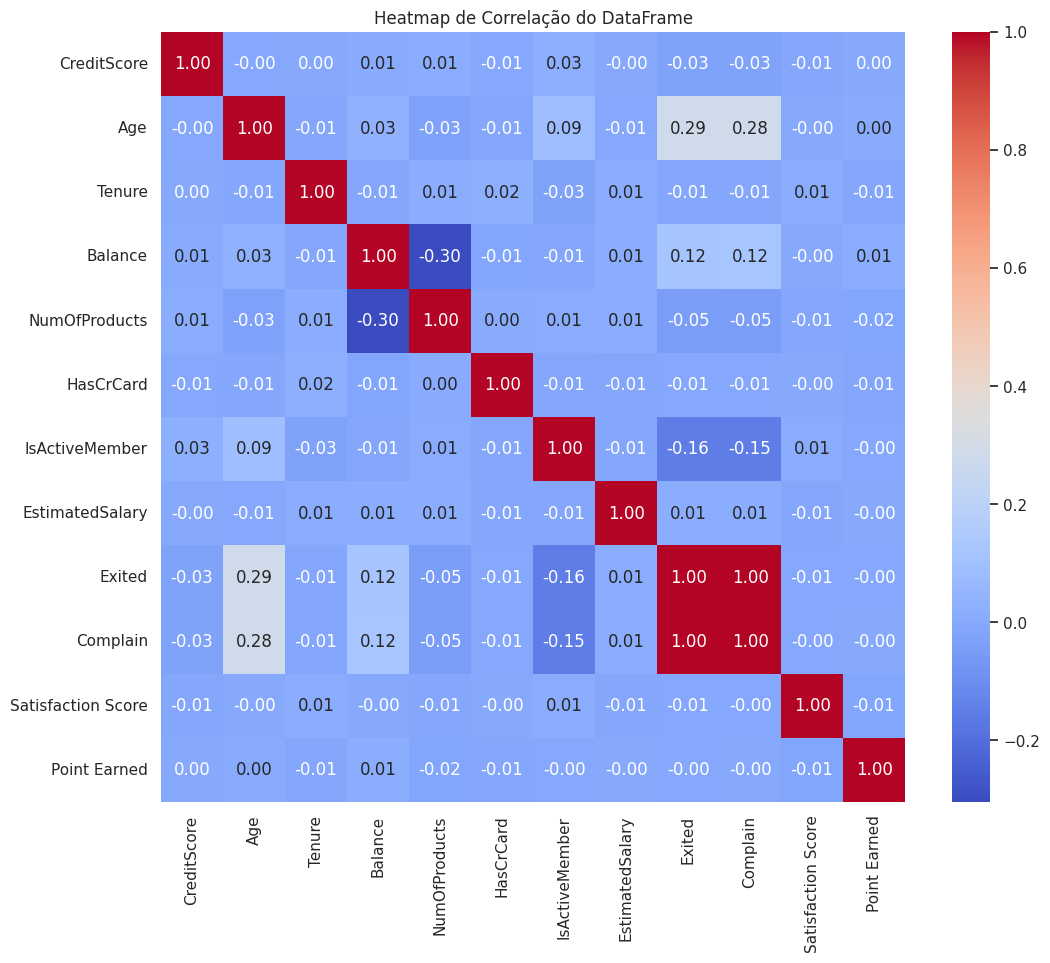

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de Correlação do DataFrame')
plt.show()

In [8]:
df = df.drop(columns=['Complain'])

Dropei a coluna `Complain` por apresentar 100% de correlação com o churn

## Análise Univariada

Nessa primeira seção de análise do notebook vou analisar a **distribuição de cada variável** no dataframe.
Dividi a análise para cada tipo de variável (categórica/contínua).

### Variáveis Categóricas

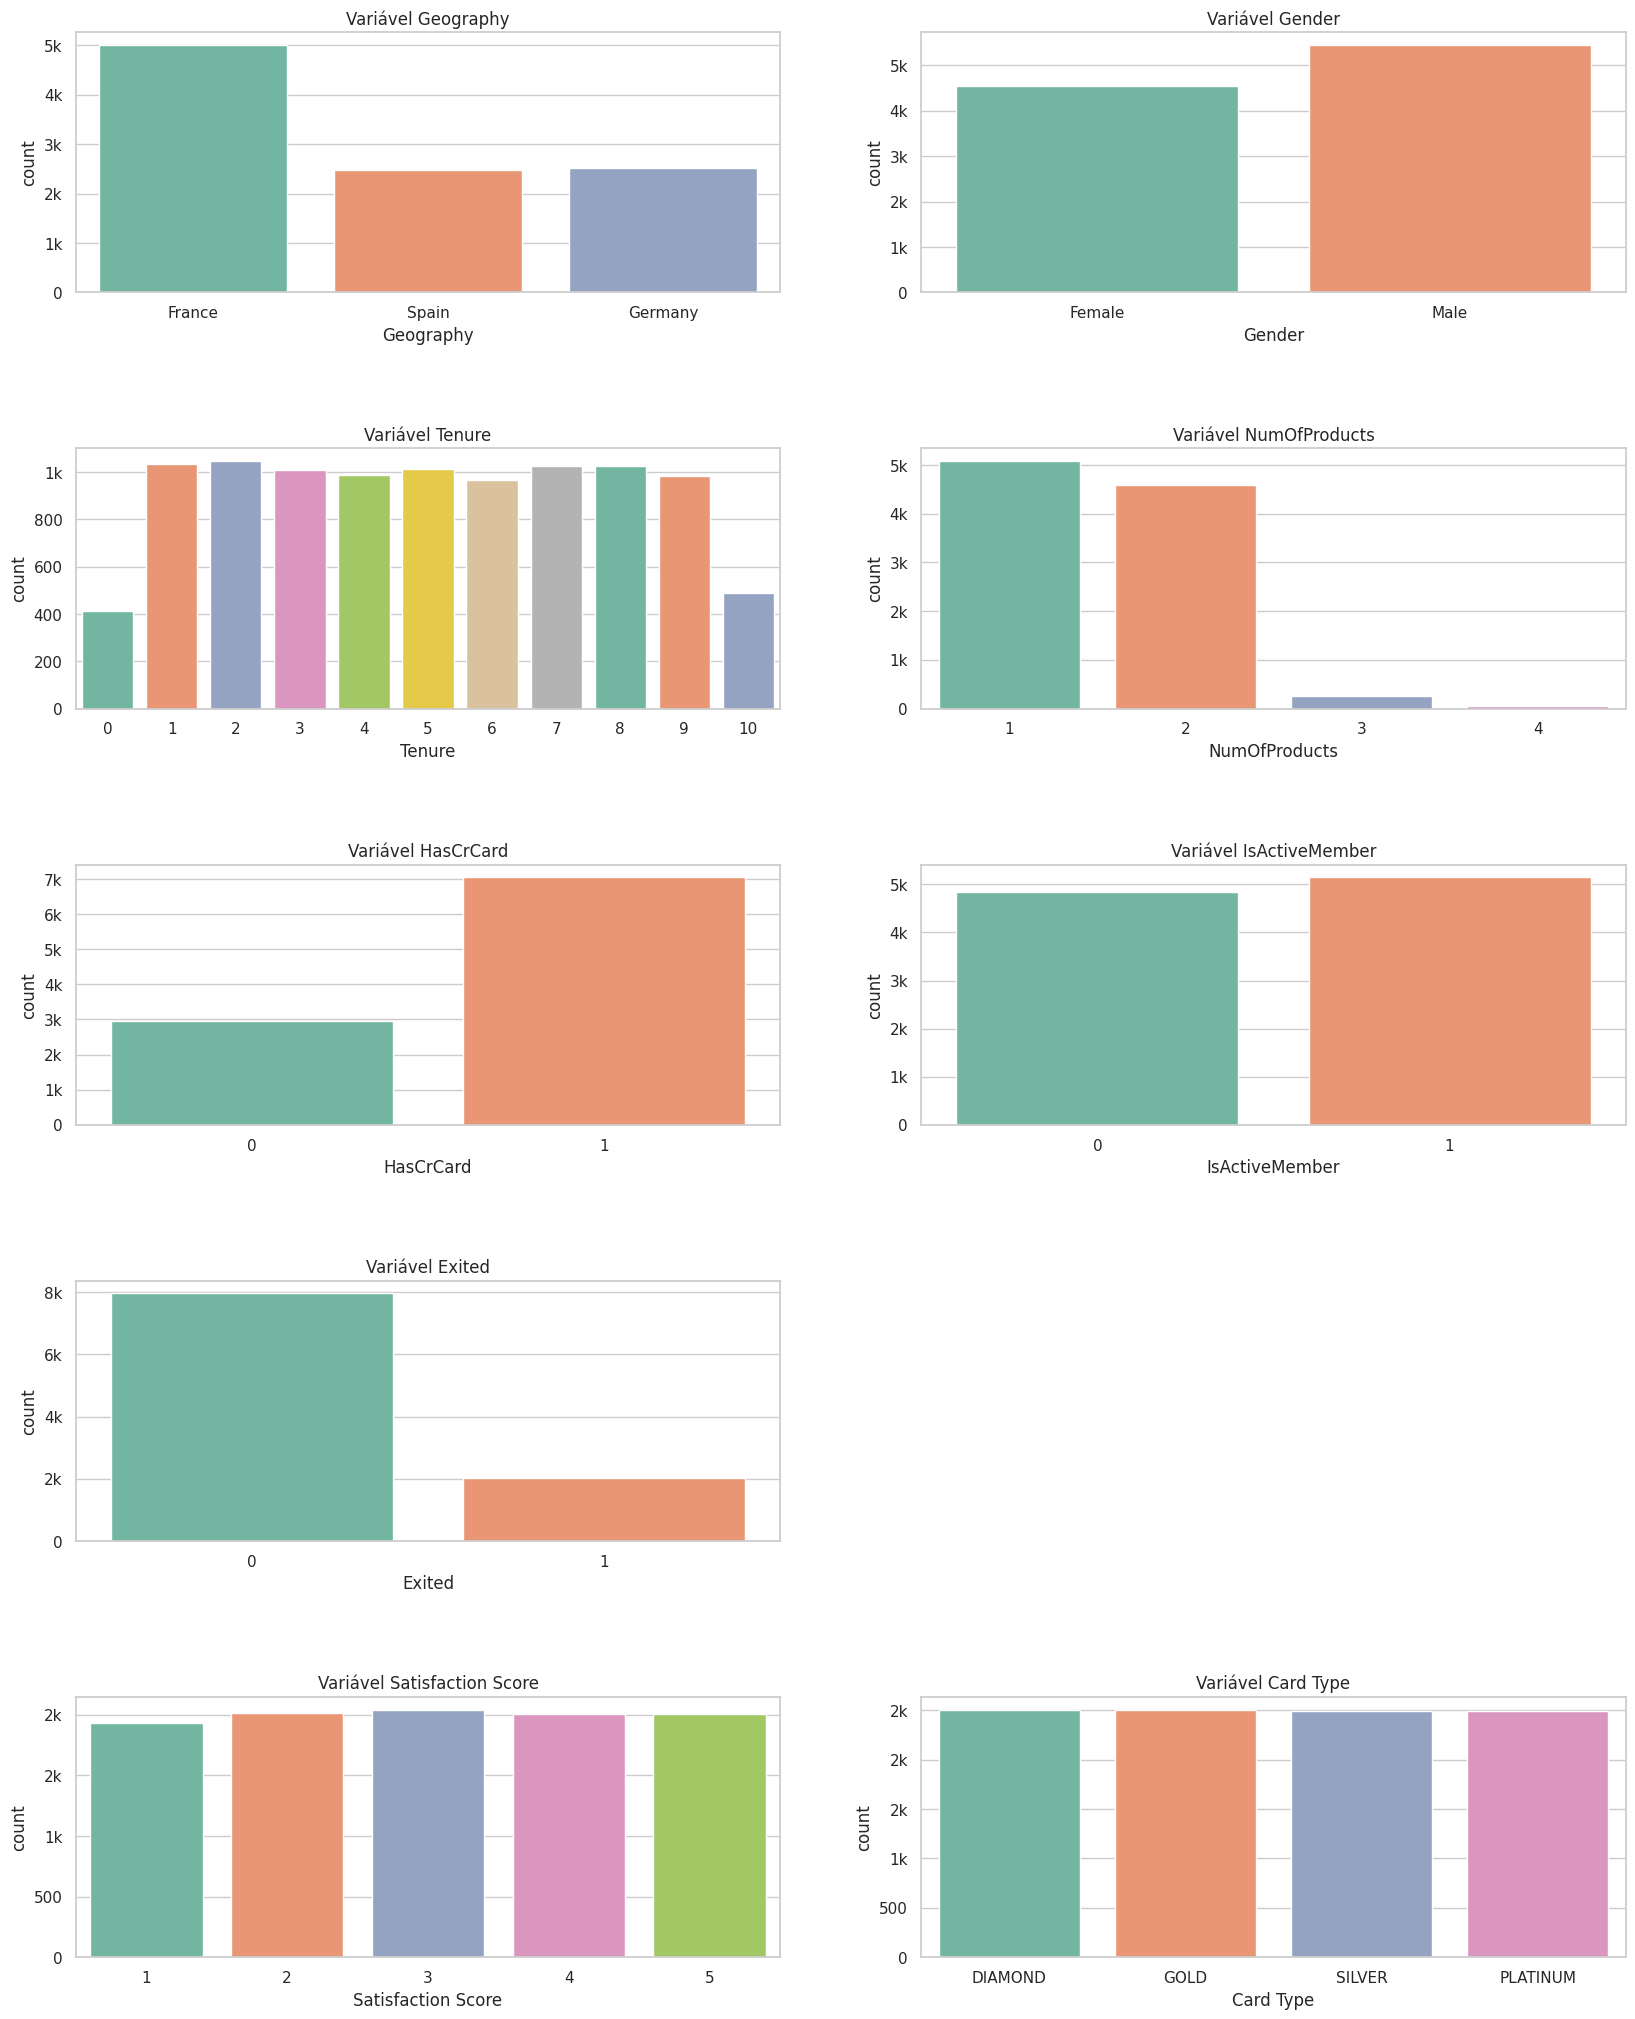

In [9]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(5, 2, figsize=(20, 25))

def format_k(x, pos):     # Função para formatar os números na casa dos milhares (k)
    if abs(x) >= 1000:
        return f'{x*1e-3:.0f}k'
    return f'{x:.0f}'

k_formatter = ticker.FuncFormatter(format_k)

plt.subplot(5, 2, 1)
plt.gca().set_title('Variável Geography')
sns.countplot(x = 'Geography', hue = 'Geography', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 2)
plt.gca().set_title('Variável Gender')
sns.countplot(x = 'Gender', hue = 'Gender', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 3)
plt.gca().set_title('Variável Tenure')
sns.countplot(x = 'Tenure', hue = 'Tenure', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 4)
plt.gca().set_title('Variável NumOfProducts')
sns.countplot(x = 'NumOfProducts', hue = 'NumOfProducts', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 5)
plt.gca().set_title('Variável HasCrCard')
sns.countplot(x = 'HasCrCard', hue = 'HasCrCard', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 6)
plt.gca().set_title('Variável IsActiveMember')
sns.countplot(x = 'IsActiveMember', hue = 'IsActiveMember', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 7)
plt.gca().set_title('Variável Exited')
sns.countplot(x = 'Exited', hue = 'Exited', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 9)
plt.gca().set_title('Variável Satisfaction Score')
sns.countplot(x = 'Satisfaction Score', hue = 'Satisfaction Score', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

plt.subplot(5, 2, 10)
plt.gca().set_title('Variável Card Type')
sns.countplot(x = 'Card Type', hue = 'Card Type', palette = 'Set2', data = df, legend=False)
plt.gca().yaxis.set_major_formatter(k_formatter)

fig.delaxes(axes[3, 1]) # removes empty axes manually since 8 plots inside 5x2 leaves space

plt.subplots_adjust(hspace=0.6, wspace=0.2)
plt.show()

É possível observar que as variáveis `NumOfProducts`, `HasCrCard` e `Exited` são desbalanceadas, isso me permite dizer que:

- A **esmagadora maioria** das pessoas tem 1 ou 2 produtos.

- Têm **mais que o dobro pessoas** com cartão de crédito em relação às que não têm

- A **variável target** está desbalanceada, informação importante para o processo de modelagem

As demais variáveis categóricas estão bem distribuídas em geral.

### Variáveis Contínuas

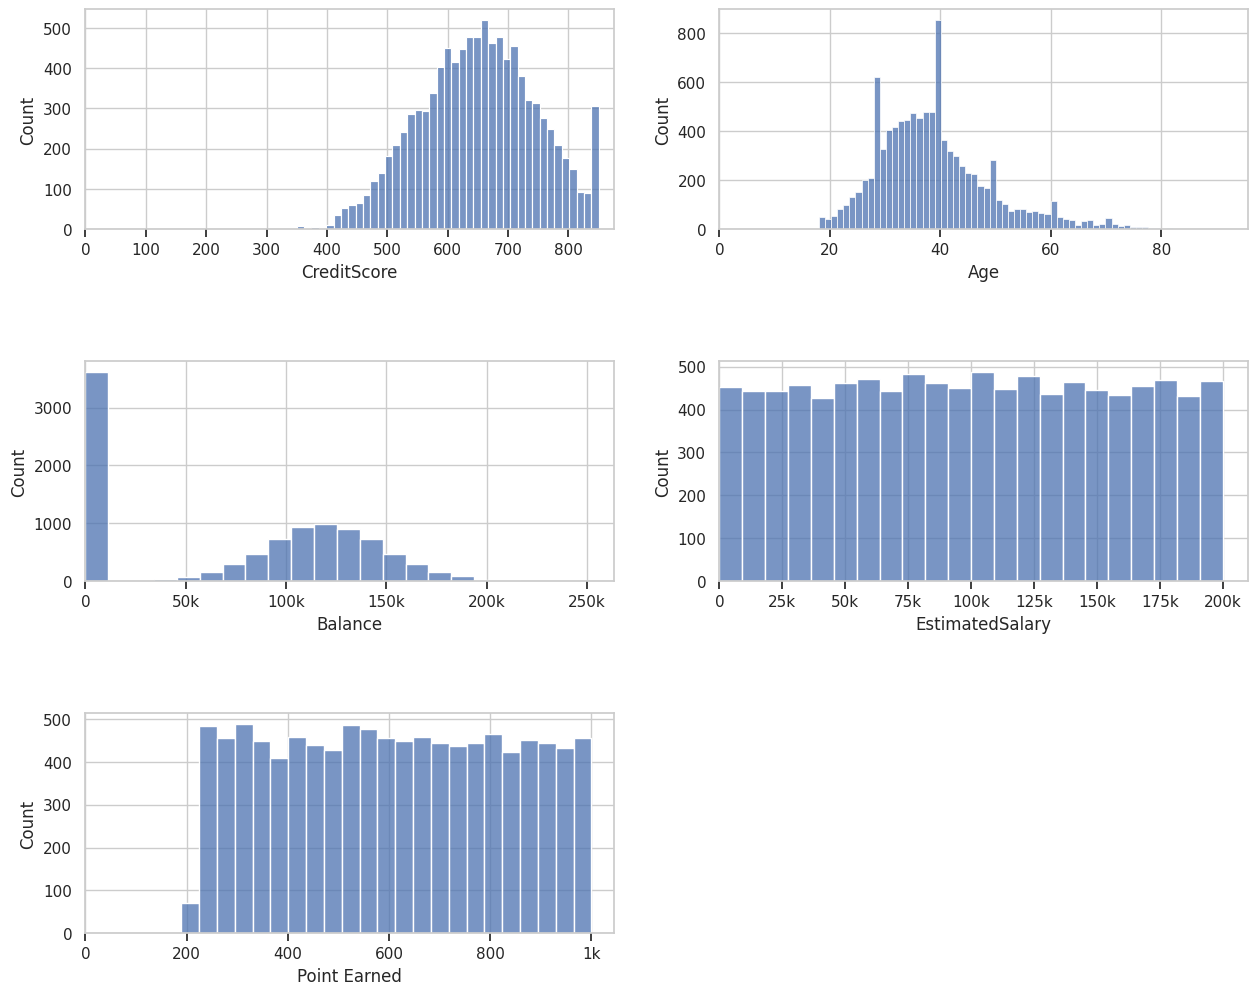

In [10]:
plt.figure(figsize = (15, 12))

plt.subplot(3, 2, 1)
ax1 = sns.histplot(x = df['CreditScore'], kde = False)
ax1.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax1.xaxis.set_major_formatter(k_formatter)
ax1.set_xlim(left=0)

plt.subplot(3, 2, 2)
ax2 = sns.histplot(x = df['Age'], kde = False)
ax2.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax2.xaxis.set_major_formatter(k_formatter)
ax2.set_xlim(left=0)

plt.subplot(3, 2, 3)
ax3 = sns.histplot(x = df['Balance'], kde = False)
ax3.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax3.xaxis.set_major_formatter(k_formatter)
ax3.set_xlim(left=0)

plt.subplot(3, 2, 4)
ax4 = sns.histplot(x = df['EstimatedSalary'], kde = False)
ax4.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax4.xaxis.set_major_formatter(k_formatter)
ax4.set_xlim(left=0)

plt.subplot(3, 2, 5)
ax5 = sns.histplot(x = df['Point Earned'], kde = False)
ax5.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
ax5.xaxis.set_major_formatter(k_formatter)
ax5.set_xlim(left=0)

plt.subplots_adjust(hspace=0.6, wspace=0.2)
plt.show()

Nas variáveis contínuas, as variáveis estão bem distribuídas em geral. `EstimatedSalary` e `PointEarned` tem praticamente o mesmo número de pessoas em todos os intervalos. Em `CreditScore` e `Age` existem distribuições normais imperfeitas, com uma leve excessão em `Balance`, que possui um grande número de pessoas com a conta zerada e o resto delas está distribuída na forma normal.

#### Boxplots

Vou usar os boxplots para ter uma análise um pouco mais técnica das distribuições das variáveis contínuas.

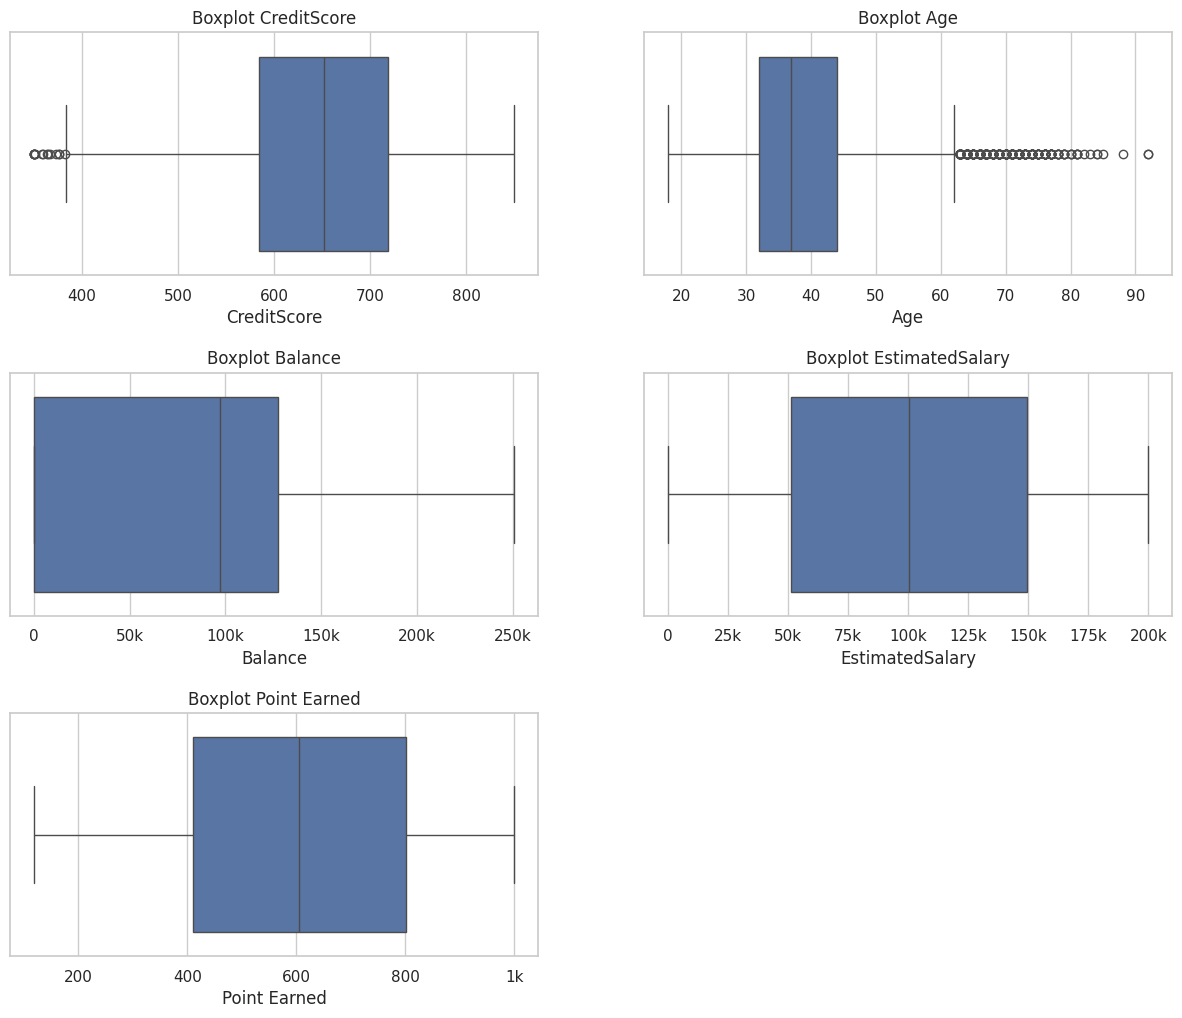

In [11]:
import matplotlib.ticker as ticker

fig = plt.figure(figsize = (15, 12))

def format_k(x, pos):
    if abs(x) >= 1000:
        return f'{x*1e-3:.0f}k'
    return f'{x:.0f}'

k_formatter = ticker.FuncFormatter(format_k)

plt.subplot(3, 2, 1)
ax1 = sns.boxplot(x = df['CreditScore'])
plt.title('Boxplot CreditScore')

plt.subplot(3, 2, 2)
ax2 = sns.boxplot(x = df['Age'])
plt.title('Boxplot Age')

plt.subplot(3, 2, 3)
ax3 = sns.boxplot(x = df['Balance'])
ax3.xaxis.set_major_formatter(k_formatter)
plt.title('Boxplot Balance')

plt.subplot(3, 2, 4)
ax4 = sns.boxplot(x = df['EstimatedSalary'])
ax4.xaxis.set_major_formatter(k_formatter)
plt.title('Boxplot EstimatedSalary')

plt.subplot(3, 2, 5)
ax5 = sns.boxplot(x = df['Point Earned'])
ax5.xaxis.set_major_formatter(k_formatter)
plt.title('Boxplot Point Earned')

plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

Analisando os boxplots, é perceptível a quantidade de outliers em `Age` e `CreditScore`, mas não é nada que possa prejudicar os modelos, pois modelos de árvore particionam por limiares e por isso são robustos a valores extremos.

## Análise Bivariada

Nessa seção vou comparar as variáveis com a target e tentar encontrar padrões, diferenças e indicadores de churn.

### Variáveis Categóricas

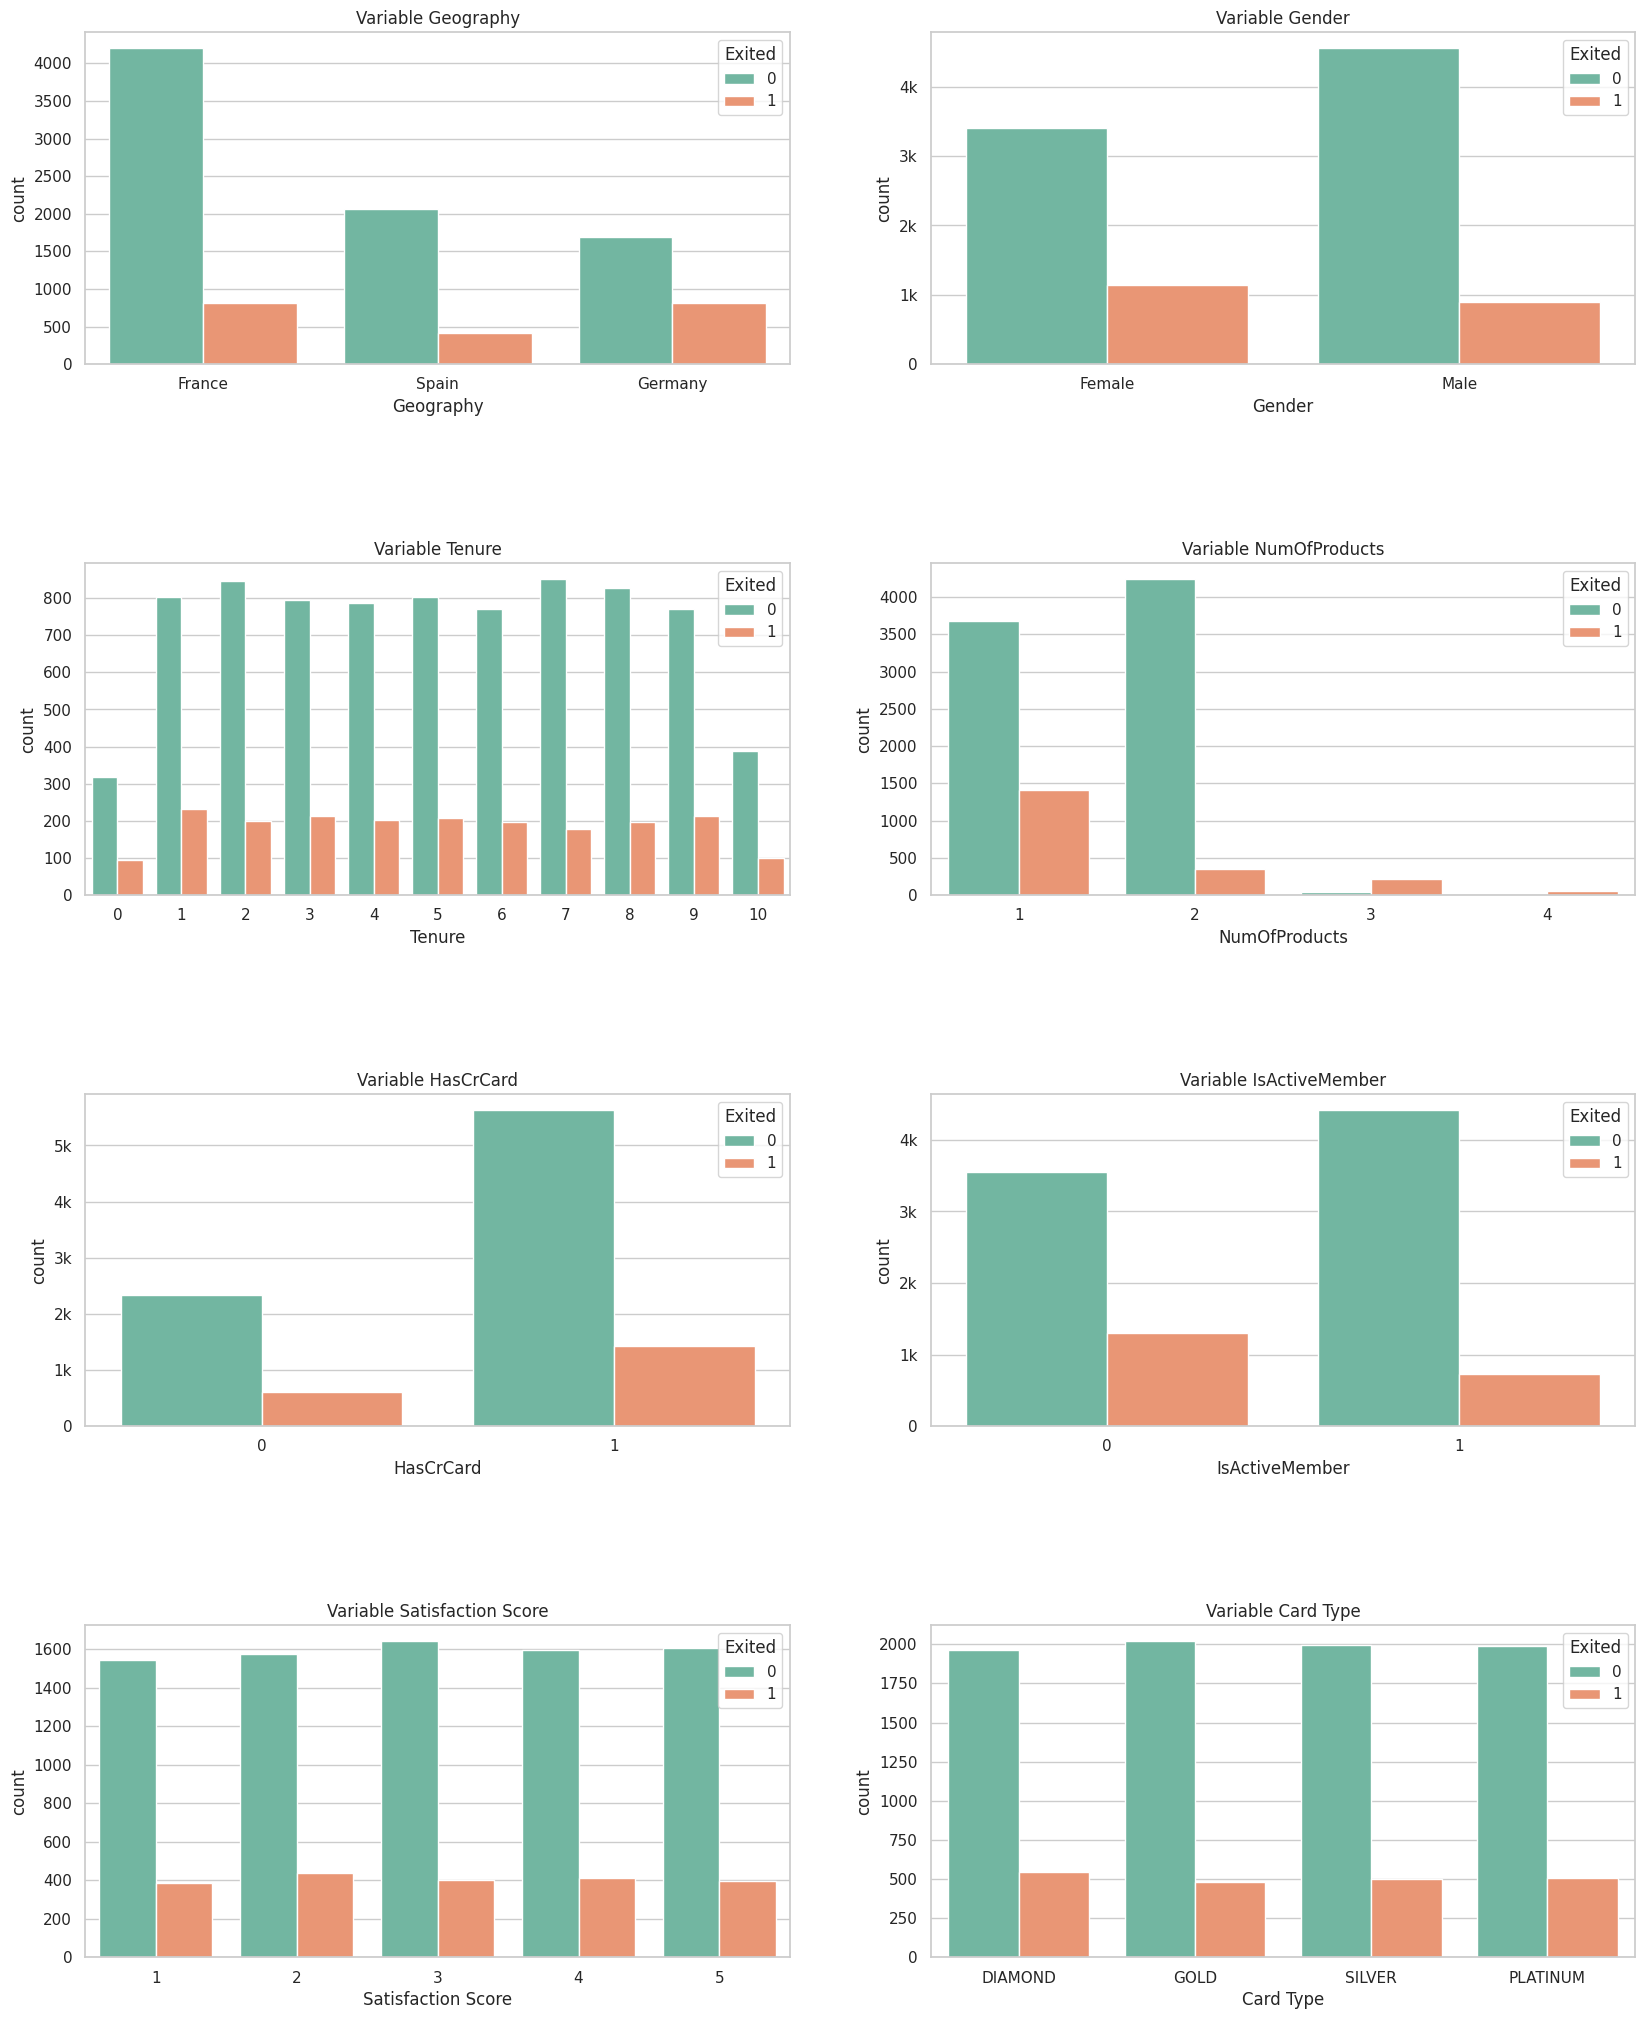

In [12]:
plt.figure(figsize = (20, 25))

plt.subplot(4, 2, 1)
ax1 = plt.gca()
ax1.set_title('Variable Geography')
sns.countplot(x = 'Geography', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 2)
ax2 = plt.gca()
ax2.set_title('Variable Gender')
ax2.yaxis.set_major_formatter(k_formatter)
sns.countplot(x = 'Gender', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 3)
ax3 = plt.gca()
ax3.set_title('Variable Tenure')
ax3.yaxis.set_major_formatter(k_formatter)
sns.countplot(x = 'Tenure', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 4)
ax4 = plt.gca()
ax4.set_title('Variable NumOfProducts')
sns.countplot(x = 'NumOfProducts', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 5)
ax5 = plt.gca()
ax5.set_title('Variable HasCrCard')
ax5.yaxis.set_major_formatter(k_formatter)
sns.countplot(x = 'HasCrCard', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 6)
ax6 = plt.gca()
ax6.set_title('Variable IsActiveMember')
ax6.yaxis.set_major_formatter(k_formatter)
sns.countplot(x = 'IsActiveMember', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 7)
ax7 = plt.gca()
ax7.set_title('Variable Satisfaction Score')
sns.countplot(x = 'Satisfaction Score', hue = 'Exited', palette = 'Set2', data = df)

plt.subplot(4, 2, 8)
ax8 = plt.gca()
ax8.set_title('Variable Card Type')
sns.countplot(x = 'Card Type', hue = 'Exited', palette = 'Set2', data = df)

plt.subplots_adjust(hspace=0.6, wspace=0.2)
plt.show()

Comparando as variáveis categóricas com a target, é possível observar dois detalhes importantes com as variáveis `Geography` e `NumOfProducts`:

- Menos de **50% dos clientes** que tem 1 produto churnam, menos de **10% dos clientes** com 2 produtos churnam, mas quando observamos os clientes com 3 e 4 produtos é uma maioria nítida que churna.

- Os clientes localizados na Alemanha possuem uma taxa de churn relativamente maior que clientes dos outros países (França e Espanha).

### Variáveis Contínuas

<Axes: xlabel='Exited', ylabel='Point Earned'>

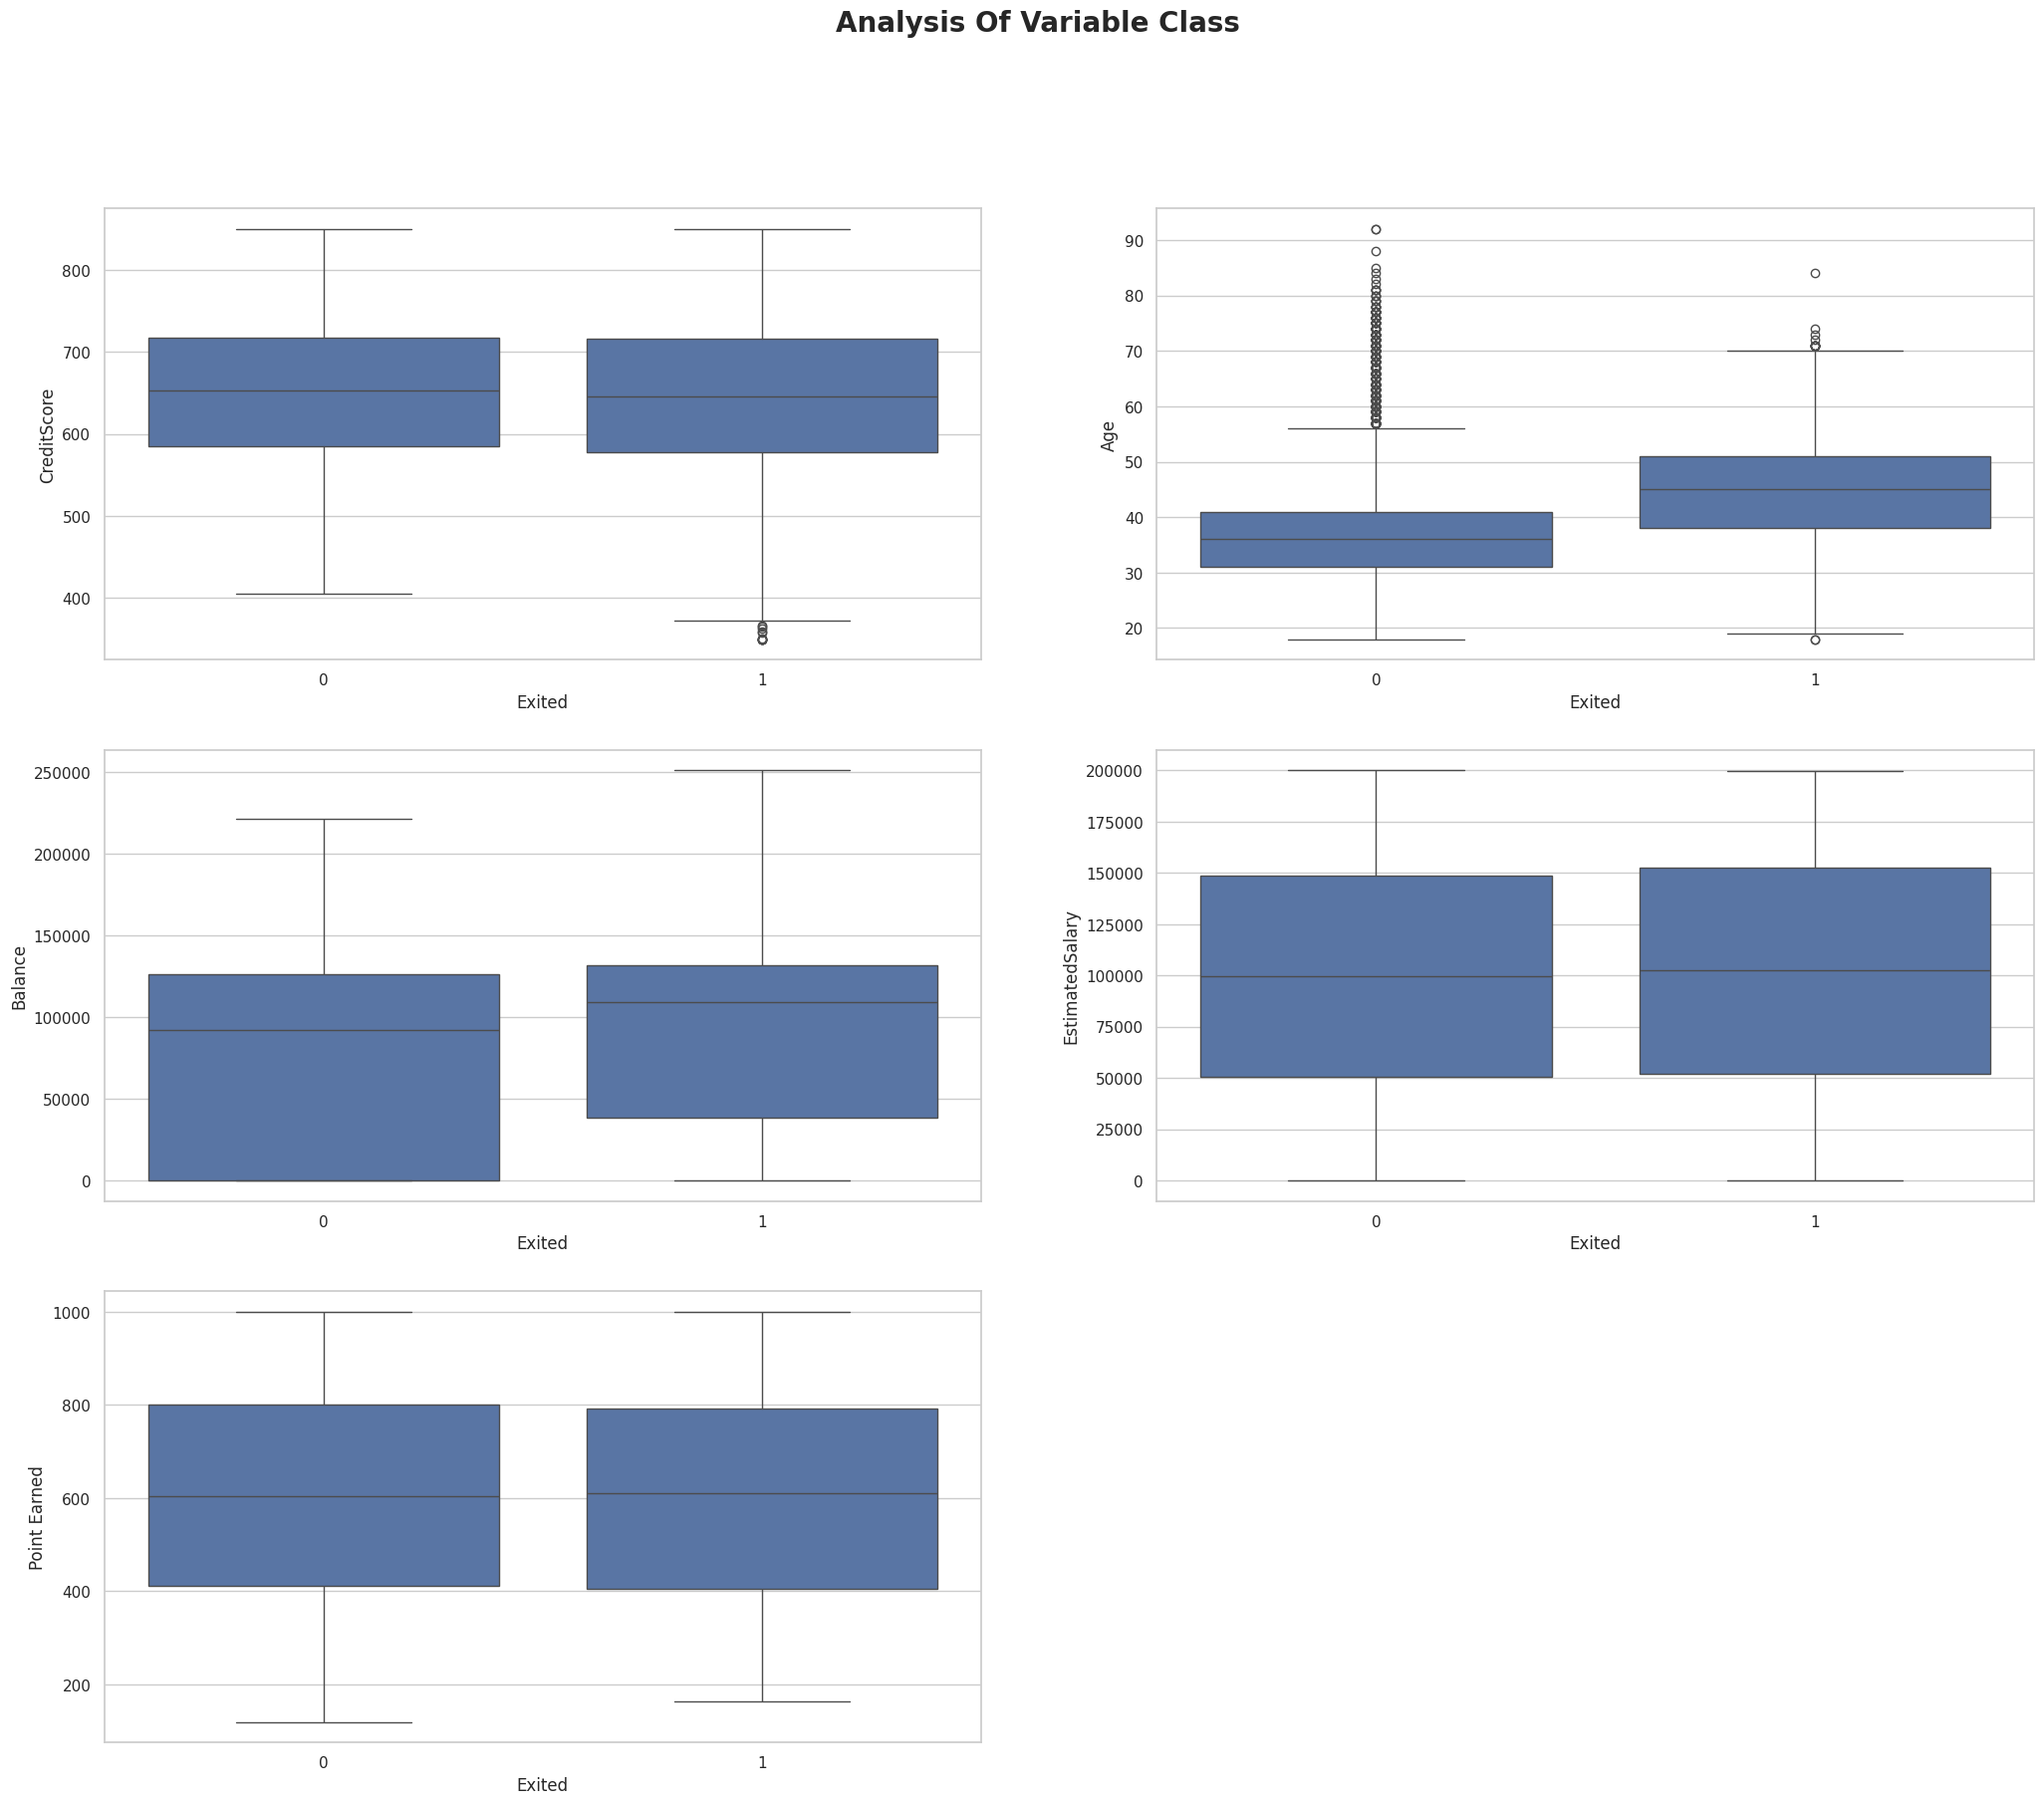

In [13]:
plt.figure(figsize = (25, 20))
plt.suptitle("Analysis Of Variable Class",fontweight="bold", fontsize=20)

plt.subplot(3,2,1)
sns.boxplot(x="Exited", y="CreditScore", data=df)

plt.subplot(3,2,2)
sns.boxplot(x="Exited", y="Age", data=df)

plt.subplot(3,2,3)
sns.boxplot(x="Exited", y="Balance", data=df)

plt.subplot(3,2,4)
sns.boxplot(x="Exited", y="EstimatedSalary", data=df)

plt.subplot(3,2,5)
sns.boxplot(x="Exited", y="Point Earned", data=df)

Entre as variáveis contínuas é possível observar que a única que apresenta uma diferença entre churn e não-churn é `Age`, que mostra uma tendência de idades maiores churnarem mais.

# Modelo

## Preparação dos dados

In [14]:
x = df.drop(columns='Exited')
y = df['Exited']

x_treino, x_teste, y_treino, y_teste = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,               # mantém a proporção de churn nos dois conjuntos
    random_state=RANDOM_STATE
)

print(f'Treino: {x_treino.shape[0]:,} linhas | churn = {y_treino.mean():.2%}')
print(f'Teste:  {x_teste.shape[0]:,} linhas | churn = {y_teste.mean():.2%}')

Treino: 8,000 linhas | churn = 20.38%
Teste:  2,000 linhas | churn = 20.40%


Pipeline de pré-processamento:

O `ColumnTransformer` contém as duas transformações necessárias juntas. Dentro de uma `Pipeline`, ele é reajustado a cada dobra da validação cruzada — é isso que elimina o vazamento.

In [15]:
cols_categoricas = ['Geography', 'Gender', 'Card Type']
cols_numericas = [c for c in x.columns if c not in cols_categoricas]

print('Categóricas:', cols_categoricas)
print('Numéricas:  ', cols_numericas)

Categóricas: ['Geography', 'Gender', 'Card Type']
Numéricas:   ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']


In [16]:
preprocessador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), cols_categoricas),
        ('num', StandardScaler(), cols_numericas),
    ]
)

## Escolhendo a métrica de otimização

Nesse contexto, é importante que o foco em otimizar o modelo seja em aumentar a métrica de **RECALL**, pois essa métrica tem relação direta com os **clientes de churn**: um recall ruim significa que o modelo não é bom para prever os clientes que teram churn.

No entanto, é uma péssima estratégia pensar em **recall puro** e aqui está o problema: **um modelo que classifica todo mundo como churn tem recall de 100%**.

Recall sozinho é uma métrica que pode ser trapaceada. Na tentativa de aumentar puramente o recall, a precisão sofre um efeito negativo quase que na mesma proporção.

A escolha aqui é o **F2-score**: a média harmônica ponderada entre precisão e recall, com peso 4× maior no recall.

$$F_\beta = (1 + \beta^2) \cdot \frac{precisão \cdot recall}{\beta^2 \cdot precisão + recall}, \quad \beta = 2$$

Isso traduz a regra de negócio correta: **perder um cliente custa mais caro do que oferecer um desconto desnecessário — mas não infinitamente mais caro.**

In [17]:
f2_scorer = make_scorer(fbeta_score, beta=2)

METRICAS = {
    'f2': f2_scorer,
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1'
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Baselines

Antes de otimizar qualquer coisa, é preciso saber o que significa "bom". Três referências:

In [18]:
dummy = DummyClassifier(strategy='most_frequent')

lr_baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

dt_baseline = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)

lista_baselines = [dummy, lr_baseline, dt_baseline]

tabelas = []
for model in lista_baselines:

    pipe = Pipeline([('prep', preprocessador), ('modelo', model)])

    resultados = cross_validate(pipe, x_treino, y_treino, cv=cv, scoring=METRICAS, n_jobs=-1)

    coluna = pd.DataFrame(resultados).filter(like='test_').mean().round(3)
    coluna.index = coluna.index.str.replace('test_', '')

    tabelas.append(coluna.rename(type(model).__name__))

pd.concat(tabelas, axis=1)

,DummyClassifier,LogisticRegression,DecisionTreeClassifier
f2,0.0,0.238,0.494
recall,0.0,0.207,0.471
precision,0.0,0.598,0.616
f1,0.0,0.307,0.534


O `DummyClassifier` zera em recall — ele nunca prevê churn. É o piso absoluto e mostra por que **acurácia não serve aqui**: chutar "ninguém sai" já acerta ~80% dos casos.

## Criação dos modelos

Aqui é a etapa de criar os modelos. Vou utilizar os algoritmos `DecisionTree`, `RandomForest` e `LogisticRegression`. Para cada modelo criado vou criar 3 versões, validar suas métricas e compará-los.

Nesse passo, para obter os melhores hiperparâmetros e maximizar as métricas de cada modelo, vou usar o `RandomizedSearchCV`, que testa algumas combinações de hiperparâmetros e devolve a melhor pela métrica escolhida.

### Decision Tree


In [19]:
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_dt = Pipeline([
    ('prep', preprocessador),
    ('modelo', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

param_rs_dt = {
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': np.linspace(4, 14, 6, dtype=int),
    'modelo__min_samples_split': np.linspace(10, 60, 4, dtype=int),
    'modelo__min_samples_leaf': np.linspace(5, 50, 4, dtype=int),
    'modelo__class_weight': [None, 'balanced'],   # penalização por peso de classe
}

total = np.prod([len(v) for v in param_rs_dt.values()])
print(f'{total} combinações x {inner_cv.get_n_splits()} dobras = {total * inner_cv.get_n_splits()} treinos')

384 combinações x 3 dobras = 1152 treinos


In [20]:
dt_nested_rs = RandomizedSearchCV(
    estimator=pipe_dt,
    param_distributions=param_rs_dt,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    return_train_score=True,
)

dt_nested_rs_scores = cross_validate(
    dt_nested_rs, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1
)

dt_nested_rs.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {dt_nested_rs_scores['test_f2'].round(3)}')
print(f'Média dos F2: {dt_nested_rs_scores['test_f2'].mean():.3f}')

F2 em cada dobra externa: [0.621 0.612 0.624 0.638 0.653]
Média dos F2: 0.630


In [21]:
print('Melhores hiperparâmetros:')
for k, v in dt_nested_rs.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  min_samples_split    = 60
  min_samples_leaf     = 20
  max_depth            = 8
  criterion            = entropy
  class_weight         = balanced


Explorando os resultados da busca

O atributo `cv_results_` guarda o desempenho de todas as combinações testadas. Vou transformar isso num DataFrame para observar o desempenho geral de cada hiperparâmetro.

In [22]:
df_cv_dt = pd.DataFrame(dt_nested_rs.cv_results_)

colunas_uteis = ([c for c in df_cv_dt.columns if c.startswith('param_')]
                 + ['mean_test_f2', 'mean_test_recall', 'mean_test_precision', 'mean_train_f2'])

df_cv_dt[colunas_uteis].sort_values('mean_test_f2', ascending=False).head(10).round(3)

,param_modelo__min_samples_split,param_modelo__min_samples_leaf,param_modelo__max_depth,param_modelo__criterion,param_modelo__class_weight,mean_test_f2,mean_test_recall,mean_test_precision,mean_train_f2
35,60,20,8,entropy,balanced,0.652,0.743,0.438,0.727
38,43,35,10,entropy,balanced,0.650,0.745,0.431,0.724
9,43,50,8,gini,balanced,0.649,0.745,0.428,0.706
1,43,35,10,gini,balanced,0.648,0.734,0.441,0.722
17,10,35,12,entropy,balanced,0.646,0.739,0.430,0.725
0,10,50,12,gini,balanced,0.646,0.739,0.429,0.706
32,26,20,8,entropy,balanced,0.645,0.736,0.432,0.730
18,60,50,12,entropy,balanced,0.642,0.728,0.436,0.702
8,60,20,14,entropy,balanced,0.640,0.722,0.441,0.750
3,10,50,8,entropy,balanced,0.639,0.723,0.435,0.699


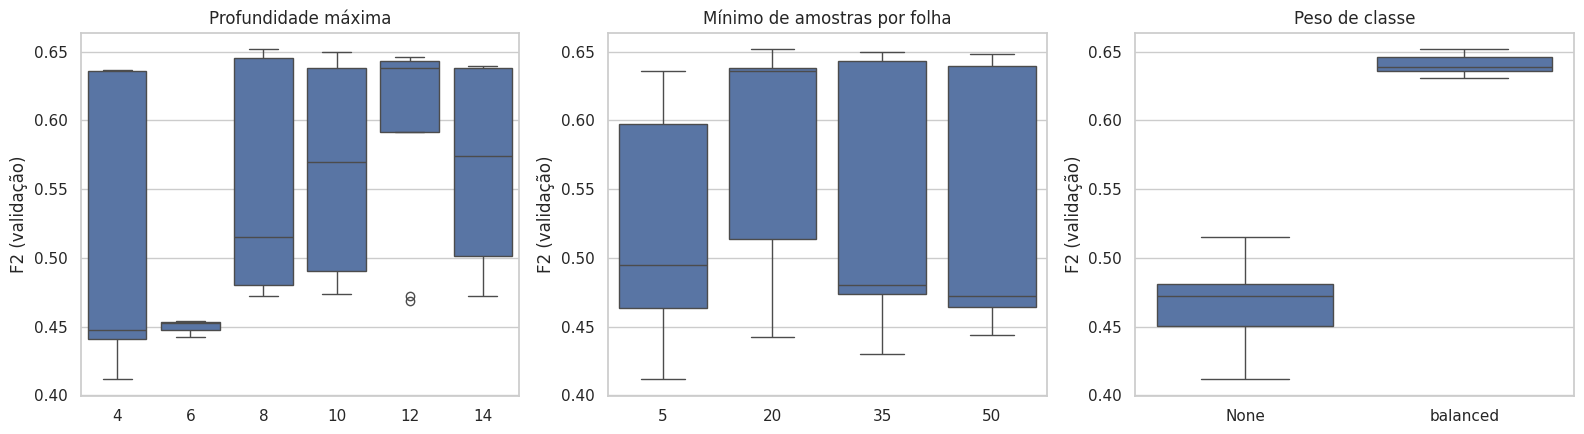

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, p, titulo in zip(
    axes,
    ['param_modelo__max_depth', 'param_modelo__min_samples_leaf', 'param_modelo__class_weight'],
    ['Profundidade máxima', 'Mínimo de amostras por folha', 'Peso de classe']
):
    dados = df_cv_dt[[p, 'mean_test_f2']].copy()

    if p != 'param_modelo__class_weight':
        ordem = sorted(dados[p].dropna().unique())
        dados[p] = dados[p].astype(str)
        ordem = [str(x) for x in ordem]
    else:
        dados[p] = dados[p].astype(str)
        ordem = sorted(dados[p].unique())

    sns.boxplot(data=dados, x=p, y='mean_test_f2', ax=ax, order=ordem)
    ax.set_title(titulo); ax.set_xlabel(''); ax.set_ylabel('F2 (validação)')

plt.tight_layout(); plt.show()

Agora é possível entender quais hiperparâmetros podem ser melhores no desempenho do modelo

#### Decision Tree + SMOTE (Oversample)

In [24]:
pipe_dt_smote = ImbPipeline([
    ('prep', preprocessador),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('modelo', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

param_rs_dt_smote = {
    'smote__sampling_strategy': [0.3, 0.5, 0.8, 1.0],
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': np.linspace(4, 14, 6, dtype=int),
    'modelo__min_samples_split': np.linspace(10, 60, 4, dtype=int),
    'modelo__min_samples_leaf': np.linspace(5, 50, 4, dtype=int),
}

total_dt = np.prod([len(v) for v in param_rs_dt_smote.values()])
print(f'{total_dt} combinações x {inner_cv.get_n_splits()} dobras = {total_dt * inner_cv.get_n_splits()} treinos')

768 combinações x 3 dobras = 2304 treinos


In [25]:
dt_nested_rs_smote = RandomizedSearchCV(
    estimator=pipe_dt_smote,
    param_distributions=param_rs_dt_smote,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

dt_nested_rs_smote_scores = cross_validate(
    dt_nested_rs_smote, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1
)

dt_nested_rs_smote.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {dt_nested_rs_smote_scores['test_f2'].round(3)}')
print(f'Média dos F2: {dt_nested_rs_smote_scores['test_f2'].mean():.3f}')

F2 em cada dobra externa: [0.614 0.637 0.636 0.601 0.598]
Média dos F2: 0.617


In [26]:
print('Melhores hiperparâmetros:')
for k, v in dt_nested_rs_smote.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  smote__sampling_strategy = 1.0
  min_samples_split    = 60
  min_samples_leaf     = 35
  max_depth            = 4
  criterion            = entropy


#### DecisionTree + Nearmiss (Undersample)

In [27]:
pipe_dt_nearmiss = ImbPipeline([
    ('prep', preprocessador),
    ('nearmiss', NearMiss()),
    ('modelo', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

param_rs_dt_nearmiss = {
    'nearmiss__version': [1, 2, 3],
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': np.linspace(4, 14, 6, dtype=int),
    'modelo__min_samples_split': np.linspace(10, 60, 4, dtype=int),
    'modelo__min_samples_leaf': np.linspace(5, 50, 4, dtype=int),
}

total_dt = np.prod([len(v) for v in param_rs_dt_nearmiss.values()])
print(f'{total_dt} combinações x {inner_cv.get_n_splits()} dobras = {total_dt * inner_cv.get_n_splits()} treinos')

576 combinações x 3 dobras = 1728 treinos


In [28]:
dt_nested_rs_nearmiss = RandomizedSearchCV(
    estimator=pipe_dt_nearmiss,
    param_distributions=param_rs_dt_nearmiss,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

dt_nested_rs_nearmiss_scores = cross_validate(
    dt_nested_rs_nearmiss, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1
)

dt_nested_rs_nearmiss.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {dt_nested_rs_nearmiss_scores['test_f2'].round(3)}')
print(f'Média dos F2: {dt_nested_rs_nearmiss_scores['test_f2'].mean():.3f}')

F2 em cada dobra externa: [0.648 0.635 0.646 0.615 0.622]
Média dos F2: 0.633


In [29]:
print('Melhores hiperparâmetros:')
for k, v in dt_nested_rs_nearmiss.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  nearmiss__version    = 2
  min_samples_split    = 10
  min_samples_leaf     = 50
  max_depth            = 14
  criterion            = entropy


### Random Forest

In [30]:
pipe_rf = Pipeline([
    ('prep', preprocessador),
    ('modelo', RandomForestClassifier(random_state=RANDOM_STATE)),
])

param_rs_rf = {
    'modelo__max_depth': [8, 12, 16],
    'modelo__min_samples_leaf': [5, 20],
    'modelo__max_features': ['sqrt', 0.5],
    'modelo__class_weight': [None, 'balanced'],
}

total = np.prod([len(v) for v in param_rs_rf.values()])
print(f'{total} combinações x {inner_cv.get_n_splits()} dobras = {total * inner_cv.get_n_splits()} treinos')

24 combinações x 3 dobras = 72 treinos


In [31]:
rf_nested_rs= RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_rs_rf,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    random_state=RANDOM_STATE,
)

rf_nested_rs_scores = cross_validate(
    rf_nested_rs, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1
)

rf_nested_rs.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {rf_nested_rs_scores['test_f2'].round(3)}')
print(f'Média dos F2: {rf_nested_rs_scores['test_f2'].mean():.3f}')

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=40. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F2 em cada dobra externa: [0.671 0.664 0.686 0.665 0.663]
Média dos F2: 0.670


In [32]:
print('Melhores hiperparâmetros:')
for k, v in rf_nested_rs.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  min_samples_leaf     = 20
  max_features         = 0.5
  max_depth            = 8
  class_weight         = balanced


#### Random Forest + SMOTE (Oversample)

In [33]:
pipe_rf_smote = ImbPipeline([
    ('prep', preprocessador),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('modelo', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_rs_rf_smote = {
    'smote__sampling_strategy': [0.3, 0.5, 0.8, 1.0],
    'modelo__max_depth': [8, 12, 16],
    'modelo__min_samples_leaf': [5, 20],
    'modelo__max_features': ['sqrt', 0.5],
}

total_rf = np.prod([len(v) for v in param_rs_rf_smote.values()])
print(f'{total_rf} combinações x {inner_cv.get_n_splits()} dobras = {total_rf * inner_cv.get_n_splits()} treinos')

48 combinações x 3 dobras = 144 treinos


In [34]:
rf_nested_rs_smote = RandomizedSearchCV(
    estimator=pipe_rf_smote,
    param_distributions=param_rs_rf_smote,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    random_state=RANDOM_STATE,
)

rf_nested_rs_smote_scores = cross_validate(
    rf_nested_rs_smote, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1
)

rf_nested_rs_smote.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {rf_nested_rs_smote_scores['test_f2'].round(3)}')
print(f'Média dos F2: {rf_nested_rs_smote_scores['test_f2'].mean():.3f}')

F2 em cada dobra externa: [0.636 0.631 0.663 0.607 0.656]
Média dos F2: 0.639


In [35]:
print('Melhores hiperparâmetros:')
for k, v in rf_nested_rs_smote.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  smote__sampling_strategy = 1.0
  min_samples_leaf     = 20
  max_features         = 0.5
  max_depth            = 8


#### Random Forest + Nearmiss (Undersample)

In [36]:
pipe_rf_nearmiss = ImbPipeline([
    ('prep', preprocessador),
    ('nearmiss', NearMiss()),
    ('modelo', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_rs_rf_nearmiss = {
    'nearmiss__version': [1, 2, 3],
    'modelo__max_depth': [8, 12, 16],
    'modelo__min_samples_leaf': [5, 20],
    'modelo__max_features': ['sqrt', 0.5],
}

total_rf = np.prod([len(v) for v in param_rs_rf_nearmiss.values()])
print(f'{total_rf} combinações x {inner_cv.get_n_splits()} dobras = {total_rf * inner_cv.get_n_splits()} treinos')

36 combinações x 3 dobras = 108 treinos


In [37]:
rf_nested_rs_nearmiss = RandomizedSearchCV(
    estimator=pipe_rf_nearmiss,
    param_distributions=param_rs_rf_nearmiss,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    random_state=RANDOM_STATE,
)

rf_nested_rs_nearmiss_scores = cross_validate(
    rf_nested_rs_nearmiss, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1
)

rf_nested_rs_nearmiss.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {rf_nested_rs_nearmiss_scores['test_f2'].round(3)}')
print(f'Média dos F2: {rf_nested_rs_nearmiss_scores['test_f2'].mean():.3f}')

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 36 is smaller than n_iter=40. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F2 em cada dobra externa: [0.652 0.638 0.666 0.64  0.659]
Média dos F2: 0.651


In [38]:
print('Melhores hiperparâmetros:')
for k, v in rf_nested_rs_nearmiss.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  nearmiss__version    = 3
  min_samples_leaf     = 5
  max_features         = sqrt
  max_depth            = 16


### Logistic Regression

In [39]:
pipe_lr = ImbPipeline([
    ('prep', preprocessador),
    ('modelo', LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1)),
])

max_iter = 1000
c = [0.001, 0.01, 0.1, 1, 10]

param_rs_lr = [ # Dois dicionários aqui porque existem parâmetros de não podem ser combinados com outros
    {'modelo__solver' : ['newton-cg', 'lbfgs'], # Apenas compatíveis com l2
     'modelo__penalty' : ['l2'],
     'modelo__max_iter' : [max_iter],
     'modelo__C' : c,
     'modelo__class_weight': [None, 'balanced']},
    {'modelo__solver' : ['liblinear'], # Compatível com l1 e l2
     'modelo__penalty' : ['l1', 'l2'],
     'modelo__max_iter' : [max_iter],
     'modelo__C' : c,
     'modelo__class_weight': [None, 'balanced']},
]

total_lr = sum(np.prod([len(v) for v in d.values()]) for d in param_rs_lr)
print(f'{total_lr} combinações x {inner_cv.get_n_splits()} dobras = {total_lr * inner_cv.get_n_splits()} treinos')

40 combinações x 3 dobras = 120 treinos


In [40]:
lr_nested_rs = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_rs_lr,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    )

lr_nested_rs_scores = cross_validate(
    lr_nested_rs, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1)

lr_nested_rs.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {lr_nested_rs_scores['test_f2'].round(3)}')
print(f'Média dos F2: {lr_nested_rs_scores['test_f2'].mean():.3f}')

F2 em cada dobra externa: [0.596 0.595 0.621 0.573 0.626]
Média dos F2: 0.602


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


In [41]:
print('Melhores hiperparâmetros:')
for k, v in lr_nested_rs.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  solver               = liblinear
  penalty              = l1
  max_iter             = 1000
  class_weight         = balanced
  C                    = 0.01


#### Logistic Regression + SMOTE

In [42]:
pipe_lr_smote = ImbPipeline([
    ('prep', preprocessador),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('modelo', LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_rs_lr_smote = [
    {'smote__sampling_strategy': [0.3, 0.5, 0.8],
     'modelo__solver' : ['newton-cg', 'lbfgs'],
     'modelo__penalty' : ['l2'],
     'modelo__max_iter' : [max_iter],
     'modelo__C' : c},
    {'smote__sampling_strategy': [0.3, 0.5, 0.8, 1.0],
     'modelo__solver' : ['liblinear'],
     'modelo__penalty' : ['l1', 'l2'],
     'modelo__max_iter' : [max_iter],
     'modelo__C' : c},
]

total_lr = sum(np.prod([len(v) for v in d.values()]) for d in param_rs_lr_smote)
print(f'{total_lr} combinações x {inner_cv.get_n_splits()} dobras = {total_lr * inner_cv.get_n_splits()} treinos')

70 combinações x 3 dobras = 210 treinos


In [43]:
lr_nested_rs_smote = RandomizedSearchCV(
    estimator=pipe_lr_smote,
    param_distributions=param_rs_lr_smote,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    )

lr_nested_rs_smote_scores = cross_validate(
    lr_nested_rs_smote, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1)

lr_nested_rs_smote.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {lr_nested_rs_smote_scores['test_f2'].round(3)}')
print(f'Média dos F2: {lr_nested_rs_smote_scores['test_f2'].mean():.3f}')

F2 em cada dobra externa: [0.563 0.581 0.598 0.571 0.606]
Média dos F2: 0.584


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


In [44]:
print('Melhores hiperparâmetros:')
for k, v in lr_nested_rs_smote.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  smote__sampling_strategy = 1.0
  solver               = liblinear
  penalty              = l1
  max_iter             = 1000
  C                    = 1


#### Logistic Regression + NearMiss

In [45]:
pipe_lr_nearmiss = ImbPipeline([
    ('prep', preprocessador),
    ('nearmiss', NearMiss()),
    ('modelo', LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1)),
])

param_rs_lr_nearmiss = [
    {'nearmiss__version': [1, 2, 3],
     'modelo__solver' : ['newton-cg', 'lbfgs'],
     'modelo__penalty' : ['l2'],
     'modelo__max_iter' : [max_iter],
     'modelo__C' : c},
    {'nearmiss__version': [1, 2, 3],
     'modelo__solver' : ['liblinear'],
     'modelo__penalty' : ['l1', 'l2'],
     'modelo__max_iter' : [max_iter],
     'modelo__C' : c},
]

total_lr = sum(np.prod([len(v) for v in d.values()]) for d in param_rs_lr_nearmiss)
print(f'{total_lr} combinações x {inner_cv.get_n_splits()} dobras = {total_lr * inner_cv.get_n_splits()} treinos')

60 combinações x 3 dobras = 180 treinos


In [46]:
lr_nested_rs_nearmiss = RandomizedSearchCV(
    estimator=pipe_lr_nearmiss,
    param_distributions=param_rs_lr_nearmiss,
    n_iter=40,
    scoring=METRICAS,
    refit='f2',
    cv=inner_cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    )

lr_nested_rs_nearmiss_scores = cross_validate(
    lr_nested_rs_nearmiss, x_treino, y_treino, cv=outer_cv, scoring=METRICAS, n_jobs=-1)

lr_nested_rs_nearmiss.fit(x_treino, y_treino)

print(f'F2 em cada dobra externa: {lr_nested_rs_nearmiss_scores['test_f2'].round(3)}')
print(f'Média dos F2: {lr_nested_rs_nearmiss_scores['test_f2'].mean():.3f}')

F2 em cada dobra externa: [0.56  0.575 0.59  0.576 0.567]
Média dos F2: 0.574


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


In [47]:
print('Melhores hiperparâmetros:')
for k, v in lr_nested_rs_nearmiss.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  nearmiss__version    = 2
  solver               = liblinear
  penalty              = l1
  max_iter             = 1000
  C                    = 0.1


## Avaliação final no conjunto de teste

Com todos modelos já criados, treinados e com métricas de validação, vou pegar aquele que teve o maior F2 e testá-lo com dados novos que ainda não foram expostos a ele. Com essa etapa final feita, será possível observar o desempenho do nosso modelo com dados reais e obter as métricas definitivas do melhor modelo.

In [48]:
scores_aninhados = {
    'Decision Tree': dt_nested_rs_scores,
    'Decision Tree + SMOTE': dt_nested_rs_smote_scores,
    'Decision Tree + NearMiss': dt_nested_rs_nearmiss_scores,
    'Random Forest': rf_nested_rs_scores,
    'Random Forest + SMOTE': rf_nested_rs_smote_scores,
    'Random Forest + NearMiss': rf_nested_rs_nearmiss_scores,
    'Logistic Regression': lr_nested_rs_scores,
    'Logistic Regression + SMOTE': lr_nested_rs_smote_scores,
    'Logistic Regression + NearMiss': lr_nested_rs_nearmiss_scores,
}

buscas = {
    'Decision Tree': dt_nested_rs,
    'Decision Tree + SMOTE': dt_nested_rs_smote,
    'Decision Tree + NearMiss': dt_nested_rs_nearmiss,
    'Random Forest': rf_nested_rs,
    'Random Forest + SMOTE': rf_nested_rs_smote,
    'Random Forest + NearMiss': rf_nested_rs_nearmiss,
    'Logistic Regression': lr_nested_rs,
    'Logistic Regression + SMOTE': lr_nested_rs_smote,
    'Logistic Regression + NearMiss': lr_nested_rs_nearmiss,
}

ranking = pd.DataFrame({
    nome: {
        'F2 aninhado': r['test_f2'].mean(),
        'desvio': r['test_f2'].std(),
        'recall': r['test_recall'].mean(),
        'precisão': r['test_precision'].mean(),
        'f1': r['test_f1'].mean(),
    }
    for nome, r in scores_aninhados.items()
}).T.sort_values('F2 aninhado', ascending=False).round(3)

display(ranking)

nome_vencedor = ranking.index[0]
melhor_modelo = buscas[nome_vencedor]
print(f'Modelo escolhido: {nome_vencedor}')

,F2 aninhado,desvio,recall,precisão,f1
Random Forest,0.670,0.009,0.715,0.535,0.612
Random Forest + NearMiss,0.651,0.011,0.707,0.494,0.582
Random Forest + SMOTE,0.639,0.020,0.651,0.594,0.621
Decision Tree + NearMiss,0.633,0.013,0.848,0.315,0.459
Decision Tree,0.630,0.014,0.712,0.433,0.537
Decision Tree + SMOTE,0.617,0.017,0.660,0.503,0.567
Logistic Regression,0.602,0.019,0.707,0.378,0.493
Logistic Regression + SMOTE,0.584,0.016,0.700,0.355,0.469
Logistic Regression + NearMiss,0.574,0.010,0.755,0.293,0.422


Modelo escolhido: Random Forest


Com o nosso modelo vencedor estabelecido, antes de testá-lo, vamos fazer uma breve análise de suas características.

In [49]:
print('Melhores hiperparâmetros:')
for k, v in melhor_modelo.best_params_.items():
    print(f'  {k.replace("modelo__", ""):<20} = {v}')

Melhores hiperparâmetros:
  min_samples_leaf     = 20
  max_features         = 0.5
  max_depth            = 8
  class_weight         = balanced


In [50]:
df_cv_melhor_modelo = pd.DataFrame(melhor_modelo.cv_results_)

coluna_score = 'mean_test_f2' if 'mean_test_f2' in df_cv_melhor_modelo.columns else 'mean_test_score'
colunas_parametros = [c for c in df_cv_melhor_modelo.columns if c.startswith('param_')]
metricas = [m for m in [coluna_score, 'mean_test_recall', 'mean_test_precision', 'mean_train_f2']
            if m in df_cv_melhor_modelo.columns]

df_cv_melhor_modelo[colunas_parametros + metricas].sort_values(coluna_score, ascending=False).head(10).round(3)

,param_modelo__min_samples_leaf,param_modelo__max_features,param_modelo__max_depth,param_modelo__class_weight,mean_test_f2,mean_test_recall,mean_test_precision
15,20,0.5,8,balanced,0.663,0.707,0.531
23,20,0.5,16,balanced,0.663,0.704,0.539
19,20,0.5,12,balanced,0.662,0.703,0.539
13,20,sqrt,8,balanced,0.659,0.704,0.524
12,5,sqrt,8,balanced,0.658,0.685,0.567
14,5,0.5,8,balanced,0.657,0.683,0.571
21,20,sqrt,16,balanced,0.648,0.688,0.528
17,20,sqrt,12,balanced,0.648,0.687,0.528
16,5,sqrt,12,balanced,0.617,0.616,0.621
18,5,0.5,12,balanced,0.612,0.609,0.626


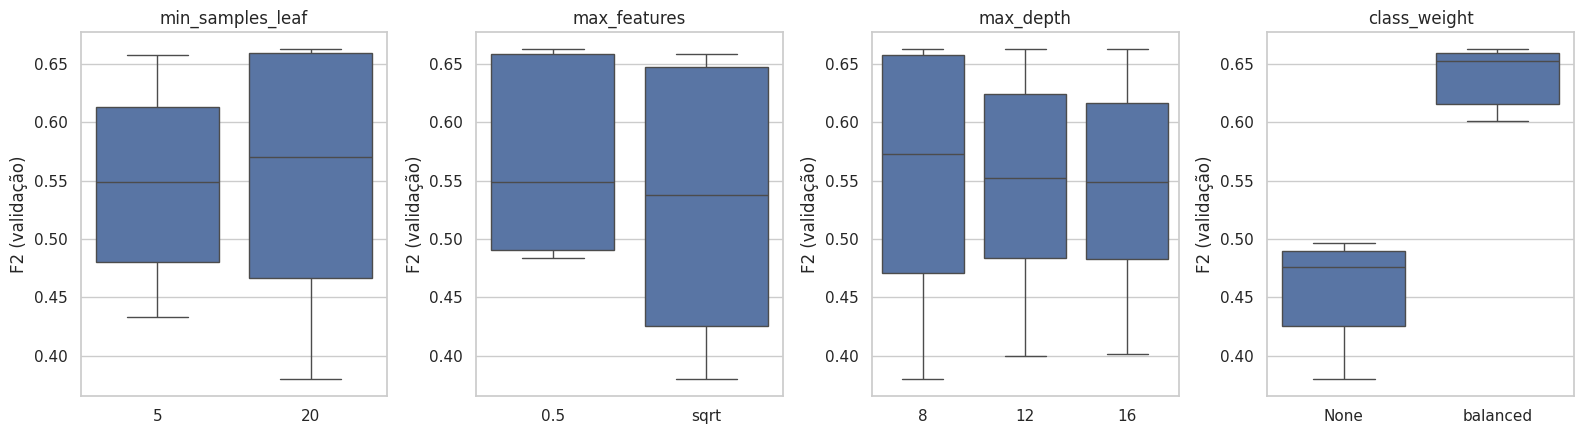

In [51]:
fig, axes = plt.subplots(1, len(colunas_parametros),
                         figsize=(4 * len(colunas_parametros), 4.5), squeeze=False)

for ax, p in zip(axes[0], colunas_parametros):
    dados = df_cv_melhor_modelo[[p, coluna_score]].copy()
    dados[p] = dados[p].map(lambda v: 'None' if pd.isna(v) else str(v))

    if pd.to_numeric(dados[p], errors='coerce').notna().all():
        ordem = sorted(dados[p].unique(), key=float)
    else:
        ordem = sorted(dados[p].unique())

    sns.boxplot(data=dados, x=p, y=coluna_score, ax=ax, order=ordem)
    ax.set_title(p.replace('param_', '').replace('modelo__', ''))
    ax.set_xlabel('')
    ax.set_ylabel('F2 (validação)')

plt.tight_layout()
plt.show()

Aqui conseguimos observar a importância do hiperparâmetro class_weight quando utilizados em dados com classes desbalanceadas.

              precision    recall  f1-score   support

       Ficou      0.927     0.835     0.879      1592
        Saiu      0.536     0.743     0.623       408

    accuracy                          0.817      2000
   macro avg      0.732     0.789     0.751      2000
weighted avg      0.847     0.817     0.827      2000

F2 no teste: 0.690


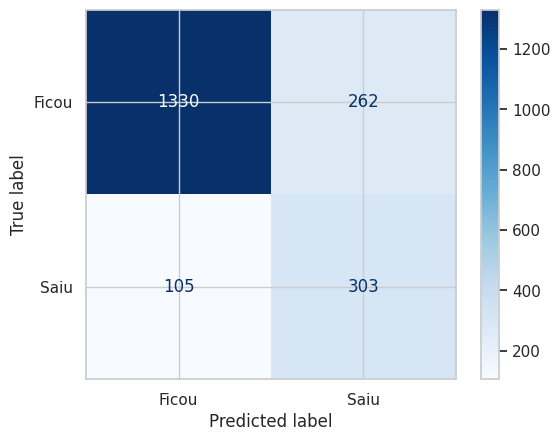

In [52]:
y_pred = melhor_modelo.predict(x_teste)

print(classification_report(y_teste, y_pred, target_names=['Ficou', 'Saiu'], digits=3))
print(f'F2 no teste: {fbeta_score(y_teste, y_pred, beta=2):.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_teste, y_pred, display_labels=['Ficou', 'Saiu'], cmap='Blues'
)
plt.show()

Agora com o desempenho real do nosso modelo podemos definir suas principais métricas reais:

- **F2 Score (métrica-alvo): 69%**
- **Recall: 74.3%**
- **Acurácia: 81.7%**
- **Precisão: 53.6%**

### Leitura de negócio

Vou colocar o desempenho do modelo no contexto de uma operação, considerando os 2.000 clientes do conjunto de teste, dos quais 408 realmente deixaram o banco:

- **303 clientes em risco foram identificados**, 74,3% dos que realmente sairiam (recall). Esses são os casos em que o time de retenção teria a chance de agir antes da saída.
- **105 clientes saíram sem nenhum alerta.** A saída do cliente sem tentativa de restenção é o erro mais caro.
- **263 clientes receberiam contato desnecessário** — pessoas que ficariam de
qualquer forma. É o erro barato: custa o valor da ação de retenção, não o cliente.

**Limitação.** A precisão de 53,6% mostra que metade dos alertas é falso positivo. Melhorar essa métrica, no caso exigiria aceitar um recall menor, ou seja, deixar mais clientes saírem sem alerta.

Na prática, para cada cliente que o modelo realmente salva, cerca de um
outro é acionado sem necessidade. Se o custo de uma ação de retenção for baixo frente ao valor de um cliente perdido, essa troca compensa. Foi exatamente com essa premissa que decidi escolher o F2 como métrica de otimização.

Entre criar uma campanha para um cliente que não sairia e perder um cliente sem tentar retê-lo, qual dos dois erros priorizar é uma decisão de negócio, não técnica, e depende da relação entre o custo da campanha de retenção e o valor de um cliente.